## Understanding of event data

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import cv2
# !wget https://rpg.ifi.uzh.ch/datasets/davis/shapes_rotation.zip
# !unzip shapes_rotation.zip


Total number of events: 72045
First timestamp: 0.0
Last timestamp: 0.999996
X coordinate range: min=4, max=239 (image width = 240)
Y coordinate range: min=1, max=179 (image height = 180)
Positive events: 31036
Negative events: 41009


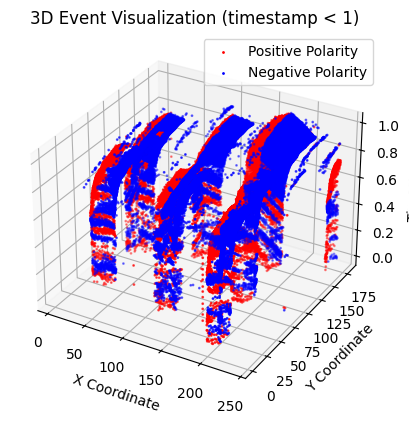

In [7]:
# Step 1: Read the file
events = []
with open("events.txt", "r") as file:
    while True:
        line = file.readline()
        if not line:
            break
        parts = line.strip().split()
        if len(parts) != 4:
            continue  # skip malformed lines

        timestamp = float(parts[0])
        if timestamp >= 1:
            break  # only take events with timestamp < 1

        x = int(parts[1])
        y = int(parts[2])
        polarity = int(parts[3])

        events.append([timestamp, x, y, polarity])

# Step 2: Split into separate lists
timestamps = []
xs = []
ys = []
polarities = []

for event in events:
    timestamps.append(event[0])
    xs.append(event[1])
    ys.append(event[2])
    polarities.append(event[3])

# Step 3: Analyze data
print(f"Total number of events: {len(events)}")
print(f"First timestamp: {min(timestamps)}")
print(f"Last timestamp: {max(timestamps)}")
print(f"X coordinate range: min={min(xs)}, max={max(xs)} (image width = 240)")
print(f"Y coordinate range: min={min(ys)}, max={max(ys)} (image height = 180)")

positive_count = sum(1 for p in polarities if p == 1)
negative_count = len(polarities) - positive_count
print(f"Positive events: {positive_count}")
print(f"Negative events: {negative_count}")

# Step 4: Split into positive and negative lists
pos_x = [x for x, p in zip(xs, polarities) if p == 1]
pos_y = [y for y, p in zip(ys, polarities) if p == 1]
pos_t = [t for t, p in zip(timestamps, polarities) if p == 1]

neg_x = [x for x, p in zip(xs, polarities) if p == 0]
neg_y = [y for y, p in zip(ys, polarities) if p == 0]
neg_t = [t for t, p in zip(timestamps, polarities) if p == 0]

# Step 5: 3D Scatter Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot positive events (red)
ax.scatter(pos_x, pos_y, pos_t, c='red', s=1, label="Positive Polarity")

# Plot negative events (blue)
ax.scatter(neg_x, neg_y, neg_t, c='blue', s=1, label="Negative Polarity")

ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_zlabel("Timestamp")
ax.set_title("3D Event Visualization (timestamp < 1)")
ax.legend()

plt.show()


## Analysing Event Data 

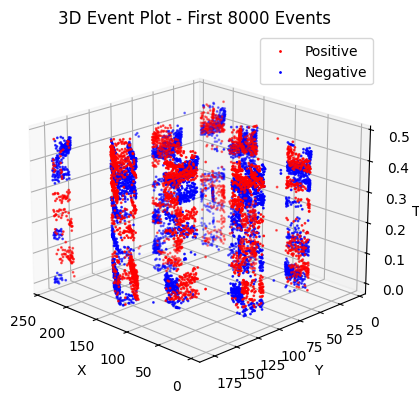

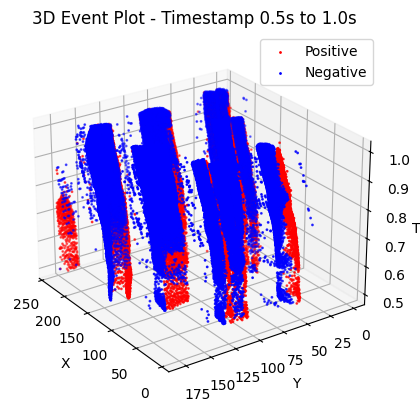


Exercise 1.1 sequence duration: 0.476492 seconds
Timestamp resolution: ~0.0000000000 seconds


In [8]:
# Load events from file
events = []
with open("events.txt", "r") as file:
    for line in file:
        parts = line.strip().split()
        if len(parts) != 4:
            continue
        timestamp = float(parts[0])
        x = int(parts[1])
        y = int(parts[2])
        polarity = int(parts[3])
        events.append([timestamp, x, y, polarity])

# ----- Exercise 1.1: First 8000 events -----
subset_8000 = events[:8000]

timestamps_8000 = [e[0] for e in subset_8000]
xs_8000 = [e[1] for e in subset_8000]
ys_8000 = [e[2] for e in subset_8000]
polarities_8000 = [e[3] for e in subset_8000]

pos_x = [x for x, p in zip(xs_8000, polarities_8000) if p == 1]
pos_y = [y for y, p in zip(ys_8000, polarities_8000) if p == 1]
pos_t = [t for t, p in zip(timestamps_8000, polarities_8000) if p == 1]

neg_x = [x for x, p in zip(xs_8000, polarities_8000) if p == 0]
neg_y = [y for y, p in zip(ys_8000, polarities_8000) if p == 0]
neg_t = [t for t, p in zip(timestamps_8000, polarities_8000) if p == 0]

fig1 = plt.figure()
ax1 = fig1.add_subplot(111, projection='3d')
ax1.scatter(pos_x, pos_y, pos_t, c='red', s=1, label="Positive")
ax1.scatter(neg_x, neg_y, neg_t, c='blue', s=1, label="Negative")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Time")
ax1.set_title("3D Event Plot - First 8000 Events")
ax1.view_init(elev=20, azim=135)  # Rotate to view shape
ax1.legend()

# ----- Exercise 1.2: Events between 0.5s and 1s -----
subset_range = [e for e in events if 0.5 <= e[0] <= 1.0]

timestamps_range = [e[0] for e in subset_range]
xs_range = [e[1] for e in subset_range]
ys_range = [e[2] for e in subset_range]
polarities_range = [e[3] for e in subset_range]

pos_x2 = [x for x, p in zip(xs_range, polarities_range) if p == 1]
pos_y2 = [y for y, p in zip(ys_range, polarities_range) if p == 1]
pos_t2 = [t for t, p in zip(timestamps_range, polarities_range) if p == 1]

neg_x2 = [x for x, p in zip(xs_range, polarities_range) if p == 0]
neg_y2 = [y for y, p in zip(ys_range, polarities_range) if p == 0]
neg_t2 = [t for t, p in zip(timestamps_range, polarities_range) if p == 0]

fig2 = plt.figure()
ax2 = fig2.add_subplot(111, projection='3d')
ax2.scatter(pos_x2, pos_y2, pos_t2, c='red', s=1, label="Positive")
ax2.scatter(neg_x2, neg_y2, neg_t2, c='blue', s=1, label="Negative")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Time")
ax2.set_title("3D Event Plot - Timestamp 0.5s to 1.0s")
ax2.view_init(elev=25, azim=145)  # Rotate to see motion direction
ax2.legend()

plt.show()

# ----- Exercise 1.3: Answer Conceptual Questions -----

# Q: How long is the sequence used during exercise 1.1 (in seconds)?
# A: It covers timestamps from the first event to the 8000th event.
duration = timestamps_8000[-1] - timestamps_8000[0]
print(f"\nExercise 1.1 sequence duration: {duration:.6f} seconds")

# Q: What’s the resolution of event timestamps?
# A: It's the smallest difference between two consecutive timestamps.
min_dt = min(t2 - t1 for t1, t2 in zip(timestamps_8000[:-1], timestamps_8000[1:]))
print(f"Timestamp resolution: ~{min_dt:.10f} seconds")

# Q: What does the time difference between events depend on?
# A: The time between events depends on the scene activity – i.e., how fast objects are moving and how much contrast change occurs in the scene.

# Q: What does positive/negative event polarity mean?
# A: Positive polarity (1) indicates brightness increase; Negative polarity (0) indicates brightness decrease at a pixel.

# Q: What is the direction of movement in exercise 1.2?
# A: You can visually determine it from the 3D plot by the trajectory of event clusters over time — for example, if they shift rightward in X as time increases, the object is moving right.


### Event frame representations

In [3]:
# Load and filter events from timestamp 1 to 2 seconds
events = []
with open("events.txt", "r") as file:
    for line in file:
        t, x, y, p = line.strip().split()
        t = float(t)
        if t > 2:
            break  # Stop reading after 2s
        if t < 1:
            continue  # Skip events before 1s
        x = int(x)
        y = int(y)
        p = 1 if int(p) == 1 else -1  # Convert polarity to {1, -1}
        events.append((t, x, y, p))

# Function to generate event frame image
def event_frame(xs, ys, ps, shape=(180, 240)):
    image = np.ones(shape) * 127  # Initialize with gray
    for x, y, p in zip(xs, ys, ps):
        if 0 <= y < shape[0] and 0 <= x < shape[1]:
            image[y, x] = 255 if p == 1 else 0  # White for +1, Black for -1
    return image.astype(np.uint8)

# Parameters
tau = 0.1  # in seconds
img_shape = (180, 240)

# Process and show frames
temp_t, temp_x, temp_y, temp_p = [], [], [], []
start_time = events[0][0]
frame_count = 0

for t, x, y, p in events:
    temp_t.append(t)
    temp_x.append(x)
    temp_y.append(y)
    temp_p.append(p)

    if t - start_time >= tau:
        frame = event_frame(temp_x, temp_y, temp_p, shape=img_shape)
        cv2.imshow("Event Frame", frame)
        cv2.waitKey(100)  # Wait for key press to show next frame
        frame_count += 1
        start_time = t
        temp_t, temp_x, temp_y, temp_p = [], [], [], []

print(f"\nGenerated {frame_count} event frames.")

cv2.destroyAllWindows()

# ---------------------- THEORETICAL QUESTIONS ----------------------

# Q: What happens with different τ values?
# A: 
# τ = 1ms → Very sparse frames; only few pixels are updated; good for precise motion capture.
# τ = 10ms → Balanced; enough data to see motion while maintaining temporal accuracy.
# τ = 100ms → Blurry, more overlap in events; loses temporal resolution but can show more object shape.



Generated 9 event frames.
